In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0428_dps_test.fits')

In [3]:
stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274399,-78.119492,48.701080,29.865618,...,256,512,0.227097,-0.661874,1,REX,1.000000,1.275339,59.770000,0.000000
1,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,78.897018,-91.391823,57.324131,58.142452,...,256,512,-0.173369,-1.161603,2,SER,2.648419,1.265829,124.010002,47.433067
2,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.714844,-73.869621,38.259602,50.303757,...,1,2,0.114889,0.235638,7,SER,1.779606,0.794439,100.040001,50.672260
3,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,63.157669,-32.048058,18.166857,88.177879,...,1,5,-0.897420,-1.292883,1,REX,1.000000,0.844727,73.330002,0.000000
4,39627739384253125,177.367218,-1.890628,0.082792,9.603887,0.054528,33.326653,-35.945473,38.321335,31.474480,...,1,2,-0.016886,0.147740,9,SER,1.508034,1.499528,62.330002,69.412030


In [4]:
model_1comp_dps = model_1comp_dps[dps_df.index]
left_2comp_dps = left_2comp_dps[dps_df.index]
right_2comp_dps = right_2comp_dps[dps_df.index]

In [5]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


In [6]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [7]:
dps_df['BPT_class_str'] = dps_df['BPT_2COMP'].map(classification_map)

In [8]:
dSF = dps_df[dps_df['BPT_class_str']=='double SF'].copy()
dAGN = dps_df[dps_df['BPT_class_str']=='double AGN'].copy()
SF_COMP = dps_df[dps_df['BPT_class_str']=='SF+COMP'].copy()
SF_AGN = dps_df[dps_df['BPT_class_str']=='SF+AGN'].copy()

In [9]:
print(len(dSF), len(dAGN), len(SF_COMP), len(SF_AGN))

9241 205 2320 749


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_35587/4191828704.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=labels, fontsize=12)


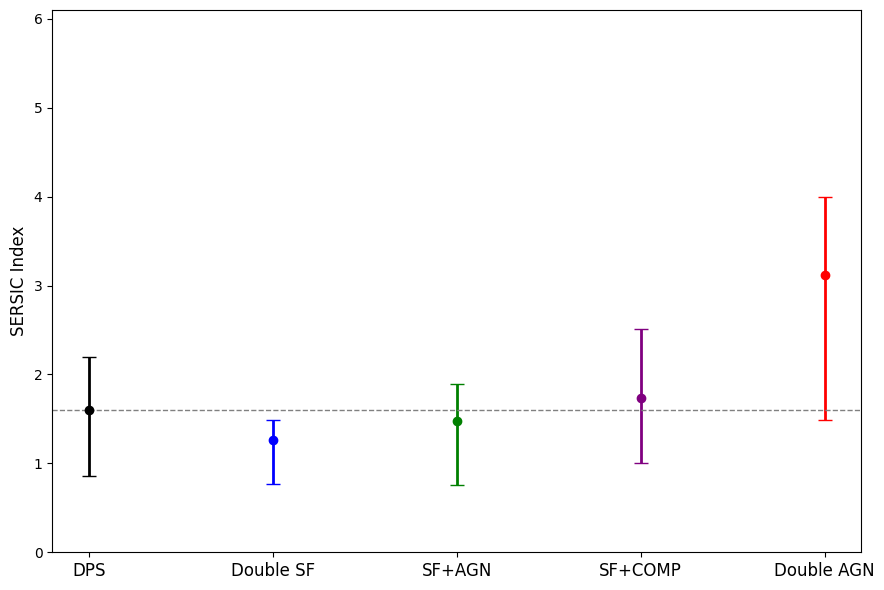

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

# Data to plot
datasets = [dps_df, dSF, SF_AGN, SF_COMP, dAGN]
labels = ['DPS', 'Double SF', 'SF+AGN', 'SF+COMP', 'Double AGN']
colors = ['k', 'blue', 'green', 'purple', 'red']

# Calculate means and quantiles for SERSIC index
means = [df['SERSIC'].mean() for df in datasets]
q25 = [df['SERSIC'].quantile(0.2) for df in datasets]
q75 = [df['SERSIC'].quantile(0.8) for df in datasets]

# Calculate asymmetric errors
errors = [np.array([means[i] - q25[i], q75[i] - means[i]]).reshape(2, 1) for i in range(len(datasets))]

# Create the error bar plot
for i, df in enumerate(datasets):
    ax.errorbar(labels[i], means[i], yerr=errors[i], fmt='o', capsize=5, color=colors[i], ecolor=colors[i], elinewidth=2)

# Add some jittered scatter points for visualization
# for i, df in enumerate(datasets):
#     # Generate jitter for x-axis
#     jitter = np.random.normal(0, 0.05, size=len(df))
#     ax.scatter([i + j for j in jitter], df['SERSIC'], alpha=0.01, color=colors[i])
ax.axhline(means[0], color='gray', linestyle='--', linewidth=1)
ax.set_xticklabels(labels=labels, fontsize=12)
ax.set_ylabel('SERSIC Index', fontsize=12)
# ax.set_title('SERSIC Index Distribution by BPT Class', fontsize=14)
ax.set_ylim(bottom=0, top=6.1)
plt.tight_layout()
# plt.savefig('./figures/Feb25/SERSIC_by_BPT_class.png')
plt.show()

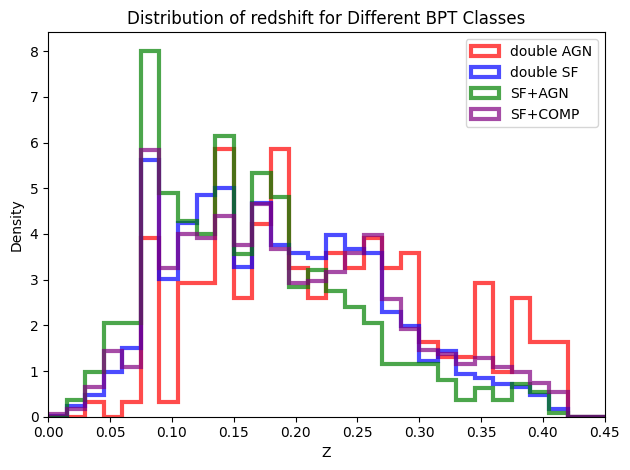

In [11]:
# plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3)
plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3)
plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3)
plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3)
plt.xlim((0, 0.45))
plt.xlabel('Z')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of redshift for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Mar26/diff_class_z_hist.png')
plt.show()

In [12]:
z_bins_bound = np.array([0, 0.15, 0.3, 0.45])

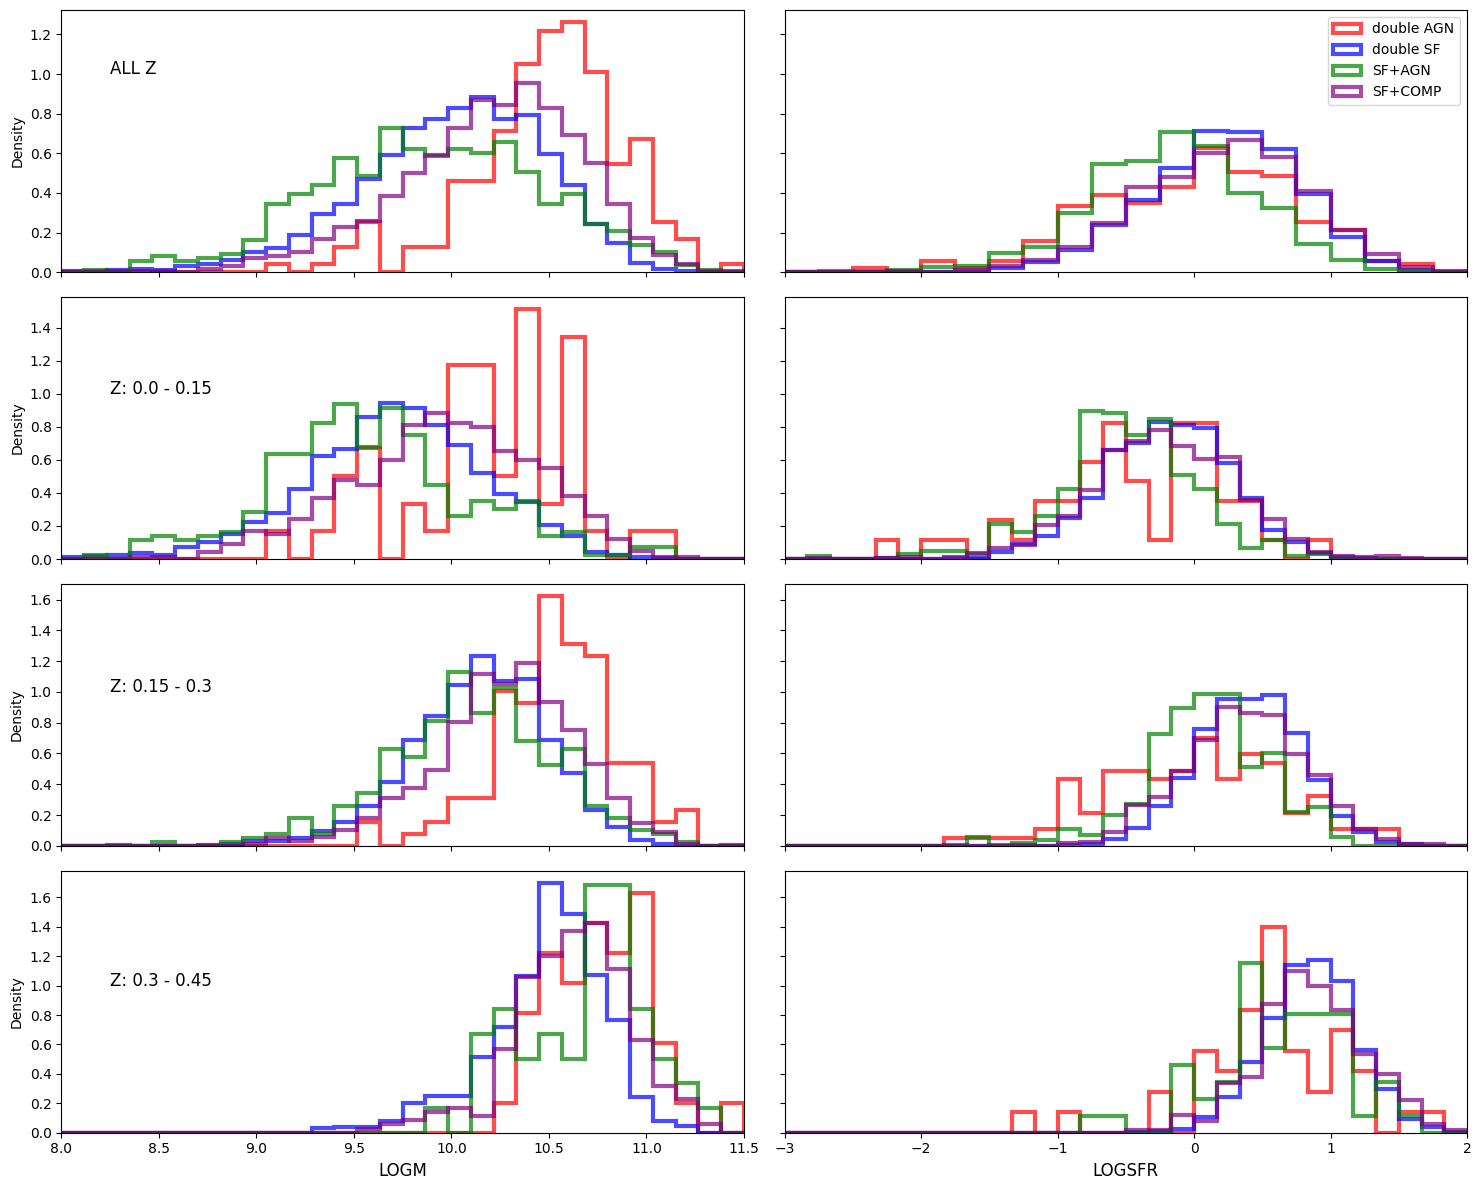

In [13]:
fig, ax = plt.subplots(4, 2, figsize=(15, 12), sharex='col', sharey='row')
plt.subplots_adjust(wspace=-0.05, hspace=-0.05)

ax[0, 0].hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 11.5), density=True, linewidth=3)
ax[0, 0].hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 11.5), density=True, linewidth=3)
ax[0, 0].hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 11.5), density=True, linewidth=3)
ax[0, 0].hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 11.5), density=True, linewidth=3)
ax[0, 0].set_xlim((8, 11.5))
ax[0, 0].text(8.25, 1, 'ALL Z', fontsize=12)

ax[0, 1].hist(dAGN['LOGSFR_1COMP'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-3, 2), density=True, linewidth=3)
ax[0, 1].hist(dSF['LOGSFR_1COMP'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-3, 2), density=True, linewidth=3)
ax[0, 1].hist(SF_AGN['LOGSFR_1COMP'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-3, 2), density=True, linewidth=3)
ax[0, 1].hist(SF_COMP['LOGSFR_1COMP'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-3, 2), density=True, linewidth=3)
ax[0, 1].set_xlim((-3, 2))


for i in range(len(z_bins_bound)-1):
    ax[i+1, 0].hist(dAGN[(dAGN['Z']>z_bins_bound[i])&(dAGN['Z']<=z_bins_bound[i+1])]['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 11.5), density=True, linewidth=3)
    ax[i+1, 0].hist(dSF[(dSF['Z']>z_bins_bound[i])&(dSF['Z']<=z_bins_bound[i+1])]['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 11.5), density=True, linewidth=3)
    ax[i+1, 0].hist(SF_AGN[(SF_AGN['Z']>z_bins_bound[i])&(SF_AGN['Z']<=z_bins_bound[i+1])]['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 11.5), density=True, linewidth=3)
    ax[i+1, 0].hist(SF_COMP[(SF_COMP['Z']>z_bins_bound[i])&(SF_COMP['Z']<=z_bins_bound[i+1])]['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 11.5), density=True, linewidth=3)
    ax[i+1, 0].set_xlim((8, 11.5))
    ax[i+1, 0].text(8.25, 1, f'Z: {z_bins_bound[i]} - {z_bins_bound[i+1]}', fontsize=12)

    ax[i+1, 1].hist(dAGN[(dAGN['Z']>z_bins_bound[i])&(dAGN['Z']<=z_bins_bound[i+1])]['LOGSFR_1COMP'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-3, 2), density=True, linewidth=3)
    ax[i+1, 1].hist(dSF[(dSF['Z']>z_bins_bound[i])&(dSF['Z']<=z_bins_bound[i+1])]['LOGSFR_1COMP'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-3, 2), density=True, linewidth=3)
    ax[i+1, 1].hist(SF_AGN[(SF_AGN['Z']>z_bins_bound[i])&(SF_AGN['Z']<=z_bins_bound[i+1])]['LOGSFR_1COMP'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-3, 2), density=True, linewidth=3)
    ax[i+1, 1].hist(SF_COMP[(SF_COMP['Z']>z_bins_bound[i])&(SF_COMP['Z']<=z_bins_bound[i+1])]['LOGSFR_1COMP'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-3, 2), density=True, linewidth=3)
    ax[i+1, 1].set_xlim((-3, 2))

ax[0, 0].set_ylabel('Density')
ax[1, 0].set_ylabel('Density')
ax[2, 0].set_ylabel('Density')
ax[3, 0].set_ylabel('Density')
ax[3, 0].set_xlabel('LOGM', fontsize=12)
ax[3, 1].set_xlabel('LOGSFR', fontsize=12)
ax[0, 1].legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('./figures/Mar26/diff_class_logm_logsfr.png')
plt.show()

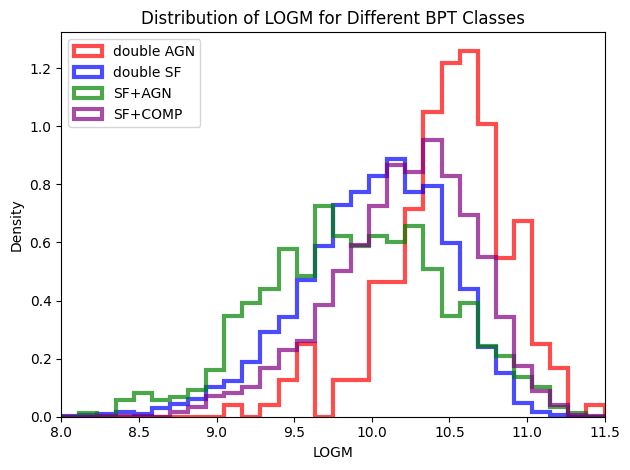

In [14]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 11.5), density=True, linewidth=3)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 11.5), density=True, linewidth=3)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 11.5), density=True, linewidth=3)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 11.5), density=True, linewidth=3)
plt.xlim((8, 11.5))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of LOGM for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/logm_distribution.png')
plt.show()

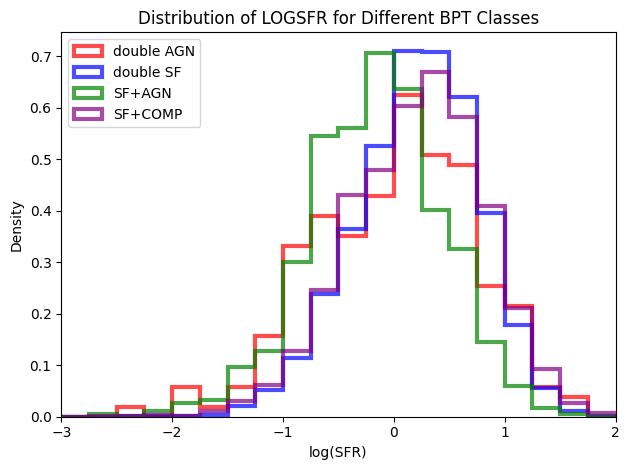

In [15]:
plt.hist(dAGN['LOGSFR_1COMP'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-3, 2), density=True, linewidth=3)
plt.hist(dSF['LOGSFR_1COMP'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-3, 2), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR_1COMP'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-3, 2), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR_1COMP'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-3, 2), density=True, linewidth=3)
plt.xlim((-3, 2))
plt.xlabel('log(SFR)')
plt.ylabel('Density')
plt.title('Distribution of LOGSFR for Different BPT Classes')
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/logsfr_distribution.png')
plt.show()